# The Deep Intuition: The Arena
Think of this like a gladiator arena for algorithms.
Instead of writing 5 different scripts to test 5 different imputers, you build one single Pipeline. Then, you hand that pipeline over to a tool called GridSearchCV.

You give GridSearchCV a "grid" (a list) of every imputer you want to test. It will:

1. Plug the first imputer (e.g., Median) into the pipeline.

2. Train the model and record the accuracy.

3. Rip the Median imputer out.

4. Plug the next imputer (e.g., KNN) into the pipeline.

5. Train the model and record the accuracy.

6. Repeat this for every option, and hand you the ultimate winner.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import warnings
warnings.filterwarnings('ignore') # Keeps our output clean

In [2]:
# create the dataset (the arena)
np.random.seed(42)
n_samples = 400

# Feature 1: Age (Normal distribution)
age = np.random.normal(35, 10, n_samples)
# Feature 2: Income (Tied to Age, plus some noise)
income = (age * 1500) + np.random.normal(0, 10000, n_samples)

# Target: Did they get approved for a premium credit card?
# (Based heavily on Income)
prob_approval = 1 / (1 + np.exp(-((income - 60000) / 10000)))
approved = np.random.binomial(1, prob_approval)

df = pd.DataFrame({'Age': age, 'Income': income, 'Approved': approved})
df

,Age,Income,Approved
0,39.967142,44006.435707,0
1,33.617357,44432.285253,1
2,41.476885,62267.765069,1
3,50.230299,75815.253784,1
4,32.658466,44487.044664,0
...,...,...,...
395,30.308243,55993.893752,0
396,17.868655,26407.430525,1
397,48.538724,79623.092586,0
398,33.854602,51065.086083,0


In [3]:
# deleting 30% of the income data randomly
missing_indices = np.random.choice(df.index, int(n_samples * 0.3), replace=False)
df.loc[missing_indices, 'Income'] = np.nan

X = df[['Age', 'Income']]
y = df['Approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# now the main thing building the pipeline
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer()),
    ('classifier', LogisticRegression())
])

In [5]:
# defining the grid
# Notice the syntax: 'stepname__parameter' (double underscore!)
# Because we didn't specify parameters for our imputers here, we just pass the objects themselves
# into a custom grid parameter we invent.

param_grid = {
    'imputer': [
        SimpleImputer(strategy='mean'),
        SimpleImputer(strategy='median'),
        KNNImputer(n_neighbors=3),
        KNNImputer(n_neighbors=7),
        IterativeImputer(random_state=42)
    ]
}

In [6]:
# grid search cv (let them fight)
print("Training models and testing imputers.. Please wait...\n")
# cv=5 means it tests every imputer 5 different times to ensure it wasn't just getting lucky

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train,  y_train)


Training models and testing imputers.. Please wait...



GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('classifier', LogisticRegression())]),
             param_grid={'imputer': [SimpleImputer(),
                                     SimpleImputer(strategy='median'),
                                     KNNImputer(n_neighbors=3),
                                     KNNImputer(n_neighbors=7),
                                     IterativeImputer(random_state=42)]},
             scoring='accuracy')

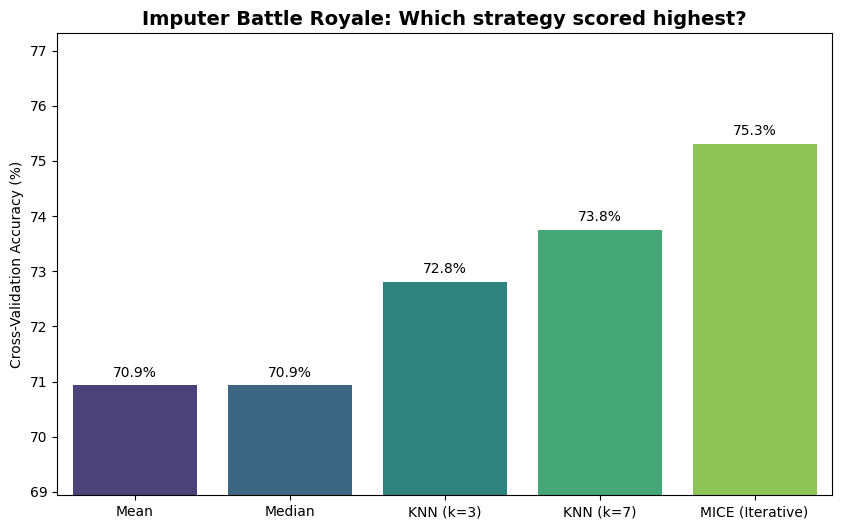

In [7]:
# Visualization the results

# Extract the scores for each imputer tested
results = pd.DataFrame(grid_search.cv_results_)
# Clean up the names for the graph
imputer_names = ['Mean', 'Median', 'KNN (k=3)', 'KNN (k=7)', 'MICE (Iterative)']
scores = results['mean_test_score'] * 100

plt.figure(figsize=(10, 6))
bars = sns.barplot(x=imputer_names, y=scores, palette='viridis')

plt.ylim(min(scores) - 2, max(scores) + 2) # Zoom in to see the differences
plt.title('Imputer Battle Royale: Which strategy scored highest?', fontsize=14, fontweight='bold')
plt.ylabel('Cross-Validation Accuracy (%)')

# Add the exact scores to the bars
for bar in bars.patches:
    bars.annotate(format(bar.get_height(), '.1f') + '%',
                   (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.show()